<div class="usecase-title">UC00231 - Urban Bike Sharing Demand Prediction with Graphical Learning</div>
<div class="usecase-authors"><b>Authored by: </b> Viswa Sai Mandava (224802004)</div>

<div class="usecase-duration"><b>Duration:</b> 90 mins</div>
<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, Pandas, Data Visualisation, Machine Learning</div>
</div>

<div class="usecase-section-header">Scenario</div>

As a City of Melbourne transport planner, I want to identify which bike sharing stations are likely to run empty or full in the next time interval so that maintenance and rebalancing teams can redistribute bikes before users are affected, reducing service failures across the network.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case you will understand:
- How to load and work with the Melbourne Bike Share historical dataset
- How to clean and parse time-series station reading data
- How to identify high-pressure stations and peak demand periods
- How to engineer lag and rolling features for temporal prediction
- How to build XGBoost Gradient Boosting models for short-term forecasting
- How to interpret MAE, RMSE and R2 metrics for a real transport dataset
- How to analyse model performance by station and by hour of day

<div class="usecase-section-header">Background</div>

Melbourne's bike sharing network operated between 2010 and 2019, providing docked bicycles at stations across the CBD and inner suburbs. The City of Melbourne collected station-level readings at regular intervals, recording how many bikes and empty docks were available at each station at each point in time.

A persistent operational challenge in bike sharing systems is rebalancing - ensuring stations have enough bikes for outgoing riders and enough empty docks for returning ones. When a station runs empty, users cannot pick up a bike. When it runs full, users cannot return one. Both situations reduce the usefulness of the network.

This use case addresses this challenge through three integrated analyses:
1. **Demand Pattern Analysis** - identifying which stations and time periods experience the most pressure
2. **Bike Availability Prediction** - predicting how many bikes will be available at a station in the next interval
3. **Empty Dock Prediction** - predicting how many empty docks will be available for returning bikes

**About the dataset:**
The Melbourne Bike Share dataset is available as a compressed CSV download from the City of Melbourne Open Data Portal. The API endpoint returns no records as the data has been archived following the end of the bike share scheme in November 2019. Download the dataset from:
https://opendatasoft-s3.s3.amazonaws.com/downloads/archive/74id-aqj9.zip

Extract the ZIP file and save the CSV as 74id-aqj9.csv in the same folder as this notebook.

---
<div class="usecase-section-header">Section 1: Environment Setup</div>

We begin by importing all libraries required for data loading, analysis, visualisation and modelling. XGBoost is installed if not already available. The Chameleon MOP company colour palette is defined for consistent plot styling throughout.

In [8]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

PRIMARY   = '#0f9295'
SECONDARY = '#08af64'
ACCENT    = '#14c9cb'
DARK      = '#056b8a'
WARN      = '#f4a623'
DANGER    = '#d94a4a'

print('Environment ready.')

Environment ready.


---
<div class="usecase-section-header">Section 2: Data Loading</div>

The dataset is loaded from the local CSV file. The full dataset contains 5.64 million rows. The full dataset of 5.64 million rows is loaded to ensure the most accurate and representative analysis and model performance. Each row represents a single station reading at a specific point in time.

In [10]:
CSV_FILE = '74id-aqj9.csv'

df_raw = pd.read_csv(CSV_FILE, low_memory=False)

print(f'Loaded   : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Columns  : {list(df_raw.columns)}')
print()
df_raw.head(5)

Loaded   : 5,644,554 rows x 16 columns
Columns  : ['ID', 'NAME', 'TERMINALNAME', 'NBBIKES', 'NBEMPTYDOCKS', 'RUNDATE', 'INSTALLED', 'TEMPORARY', 'LOCKED', 'LASTCOMMWITHSERVER', 'LATESTUPDATETIME', 'REMOVALDATE', 'INSTALLDATE', 'LAT', 'LONG', 'LOCATION']



,ID,NAME,TERMINALNAME,NBBIKES,NBEMPTYDOCKS,RUNDATE,INSTALLED,TEMPORARY,LOCKED,LASTCOMMWITHSERVER,LATESTUPDATETIME,REMOVALDATE,INSTALLDATE,LAT,LONG,LOCATION
0,2,Harbour Town - Docklands Dve - Docklands,60000,10,11,20170422134506,True,False,False,1492832566010,1.492833e+12,NaN,1.313725e+12,-37.814022,144.939521,"(-37.814022, 144.939521)"
1,4,Federation Square - Flinders St / Swanston St ...,60001,9,18,20170422134506,True,False,False,1492832631727,1.492832e+12,NaN,NaN,-37.817523,144.967814,"(-37.817523, 144.967814)"
2,6,State Library - Swanston St / Little Lonsdale ...,60003,1,10,20170422134506,True,False,False,1492832015231,1.492832e+12,NaN,NaN,-37.810702,144.964417,"(-37.810702, 144.964417)"
3,7,Bourke Street Mall - 205 Bourke St - City,60004,4,7,20170422134506,True,False,False,1492832218661,1.492830e+12,NaN,NaN,-37.813088,144.967437,"(-37.813088, 144.967437)"
4,8,Melbourne Uni - Tin Alley - Carlton,60005,8,11,20170422134506,True,False,False,1492832103674,1.492769e+12,NaN,NaN,-37.796250,144.960858,"(-37.79625, 144.960858)"


**Section 2 Insights:** The dataset contains 16 columns. The key columns are NAME (station name), NBBIKES (bikes available), NBEMPTYDOCKS (empty docks available) and RUNDATE (timestamp stored as YYYYMMDDHHMMSS integer format). These four columns drive all three use case analyses.

---
<div class="usecase-section-header">Section 3: Data Cleaning and Preparation</div>

Before analysis can begin the raw data needs to be cleaned and structured. This involves parsing the timestamp column into proper datetime format, extracting time-based features needed for both analysis and modelling, and checking for missing values. Understanding data quality at this stage is essential before drawing conclusions.

In [13]:
df = df_raw.copy()
df.columns = [c.upper() for c in df.columns]

df['RUNDATE']  = df['RUNDATE'].astype(str).str.strip()
df['datetime'] = pd.to_datetime(df['RUNDATE'], format='%Y%m%d%H%M%S', errors='coerce')

df['hour']        = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['day_name']    = df['datetime'].dt.day_name()
df['month']       = df['datetime'].dt.month
df['month_name']  = df['datetime'].dt.month_name()
df['year']        = df['datetime'].dt.year
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

df['NBBIKES']      = pd.to_numeric(df['NBBIKES'],      errors='coerce')
df['NBEMPTYDOCKS'] = pd.to_numeric(df['NBEMPTYDOCKS'], errors='coerce')
df = df.dropna(subset=['datetime', 'NBBIKES', 'NBEMPTYDOCKS', 'NAME'])

print('=== Data Cleaning Summary ===')
print(f'Rows after cleaning : {df.shape[0]:,}')
print(f'Date range          : {df["datetime"].min()} to {df["datetime"].max()}')
print(f'Unique stations     : {df["NAME"].nunique()}')
print(f'Years covered       : {sorted(df["year"].unique())}')
print()
print('Summary statistics:')
print(df[['NBBIKES', 'NBEMPTYDOCKS']].describe().round(2))

=== Data Cleaning Summary ===
Rows after cleaning : 5,644,554
Date range          : 2015-04-22 12:36:42 to 2018-09-04 10:00:10
Unique stations     : 119
Years covered       : [2015, 2016, 2017, 2018]

Summary statistics:
          NBBIKES  NBEMPTYDOCKS
count  5644554.00    5644554.00
mean         9.31          8.45
std          6.28          6.05
min          0.00          0.00
25%          5.00          4.00
50%          8.00          7.00
75%         12.00         12.00
max         39.00         39.00


To understand the shape of our key variables, we plot the distribution of bike counts and empty dock counts across all readings. This tells us whether most readings cluster around low values, high values, or somewhere in the middle, and helps us spot any unusual patterns in the data.

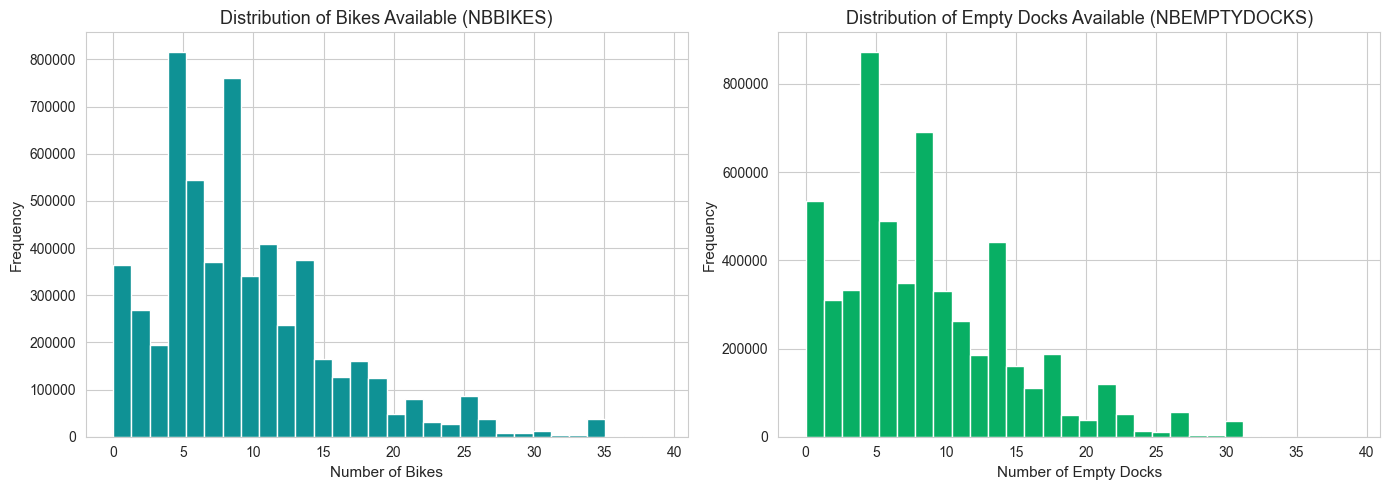

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['NBBIKES'].dropna(),      bins=30, color=PRIMARY,   edgecolor='white')
axes[0].set_title('Distribution of Bikes Available (NBBIKES)')
axes[0].set_xlabel('Number of Bikes')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['NBEMPTYDOCKS'].dropna(), bins=30, color=SECONDARY, edgecolor='white')
axes[1].set_title('Distribution of Empty Docks Available (NBEMPTYDOCKS)')
axes[1].set_xlabel('Number of Empty Docks')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

We now look at each station individually to understand which stations tend to have the most bikes available on average and how many readings we have per station. This gives us a baseline understanding of station-level behaviour before we move into pressure analysis.

In [17]:
station_summary = df.groupby('NAME').agg(
    avg_bikes       = ('NBBIKES',      'mean'),
    avg_empty_docks = ('NBEMPTYDOCKS', 'mean'),
    total_readings  = ('NBBIKES',      'count')
).round(2).sort_values('avg_bikes', ascending=False)

print(f'Total unique stations in sample: {len(station_summary)}')
print()
print('Top 10 stations by average bikes available:')
print(station_summary.head(10).to_string())

Total unique stations in sample: 119

Top 10 stations by average bikes available:
                                                            avg_bikes  avg_empty_docks  total_readings
NAME                                                                                                  
Luna Park - Lower Esp - St Kilda                                27.20            11.32           91065
St Kilda - Luna Park                                            25.60            12.84           21916
Waterfront City - New Quay / Harbour Esplanade - Docklands      23.67             3.33               3
Beach St  Port Melbourne                                        21.47            15.55           21916
Southern Cross Station - Spencer St - City                      18.77             7.89           91065
Federation Square                                               18.57             7.84           21917
MSAC - Aughtie Dve - Albert Park                                17.76             9.07        

**Section 3 Insights:** The dataset is clean with no missing values in key columns after parsing. Both NBBIKES and NBEMPTYDOCKS follow a right-skewed distribution meaning most readings show low counts with occasional higher values. This is consistent with a busy bike sharing network where stations frequently cycle between states. The station overview shows significant variation in average availability across stations indicating that some are structurally busier than others.

---
<div class="usecase-section-header">Section 4: Use Case 1 - Demand Pattern Analysis</div>

The first use case focuses on understanding when and where demand pressure occurs across the network. A station is considered under pressure when it is nearly empty (2 or fewer bikes) or nearly full (2 or fewer empty docks). Analysing these pressure events by hour and day reveals the most critical time windows for operational intervention.

<p class="usecase-subsection-header">4.1 Station Pressure Analysis</p>

In [21]:
df['nearly_empty']   = (df['NBBIKES'] <= 2).astype(int)
df['nearly_full']    = (df['NBEMPTYDOCKS'] <= 2).astype(int)
df['under_pressure'] = ((df['nearly_empty'] == 1) | (df['nearly_full'] == 1)).astype(int)

print('=== Station Pressure Summary ===')
print(f'Overall pressure rate : {df["under_pressure"].mean()*100:.1f}%')
print(f'Nearly empty rate     : {df["nearly_empty"].mean()*100:.1f}%')
print(f'Nearly full rate      : {df["nearly_full"].mean()*100:.1f}%')

=== Station Pressure Summary ===
Overall pressure rate : 26.1%
Nearly empty rate     : 11.2%
Nearly full rate      : 15.0%


<p class="usecase-subsection-header">4.2 Hourly and Daily Patterns</p>

Understanding how availability changes throughout the day and across the week is fundamental to identifying when rebalancing teams should prioritise their efforts.

We calculate the average number of bikes and empty docks available at each hour of the day across all stations and all readings. Plotting these two lines together shows how supply shifts throughout the day and helps identify the hours when the network is under the most strain.

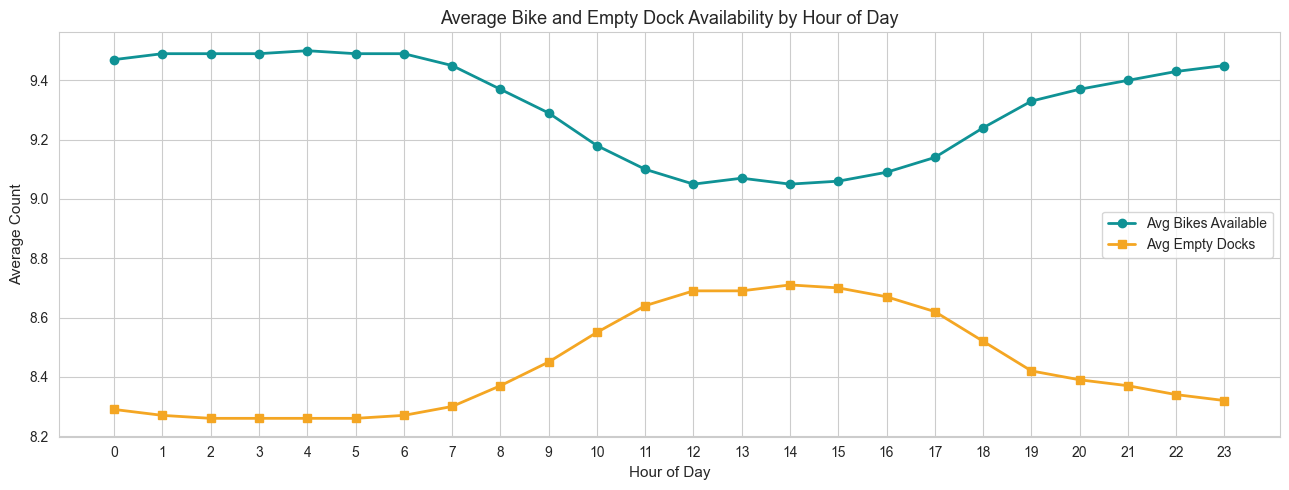

Hour with lowest avg bike availability: 12:00 (9.05 avg bikes)


In [24]:
hourly = df.groupby('hour')[['NBBIKES', 'NBEMPTYDOCKS']].mean().round(2)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hourly.index, hourly['NBBIKES'],      marker='o', color=PRIMARY,   linewidth=2, label='Avg Bikes Available')
ax.plot(hourly.index, hourly['NBEMPTYDOCKS'], marker='s', color=WARN,      linewidth=2, label='Avg Empty Docks')
ax.set_title('Average Bike and Empty Dock Availability by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Count')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

print(f'Hour with lowest avg bike availability: {hourly["NBBIKES"].idxmin()}:00 ({hourly["NBBIKES"].min():.2f} avg bikes)')

We now look at how availability varies across days of the week and compare weekdays versus weekends. This tells us whether the network is primarily used for commuting (higher weekday demand) or leisure (higher weekend demand), which has implications for when rebalancing resources should be deployed.

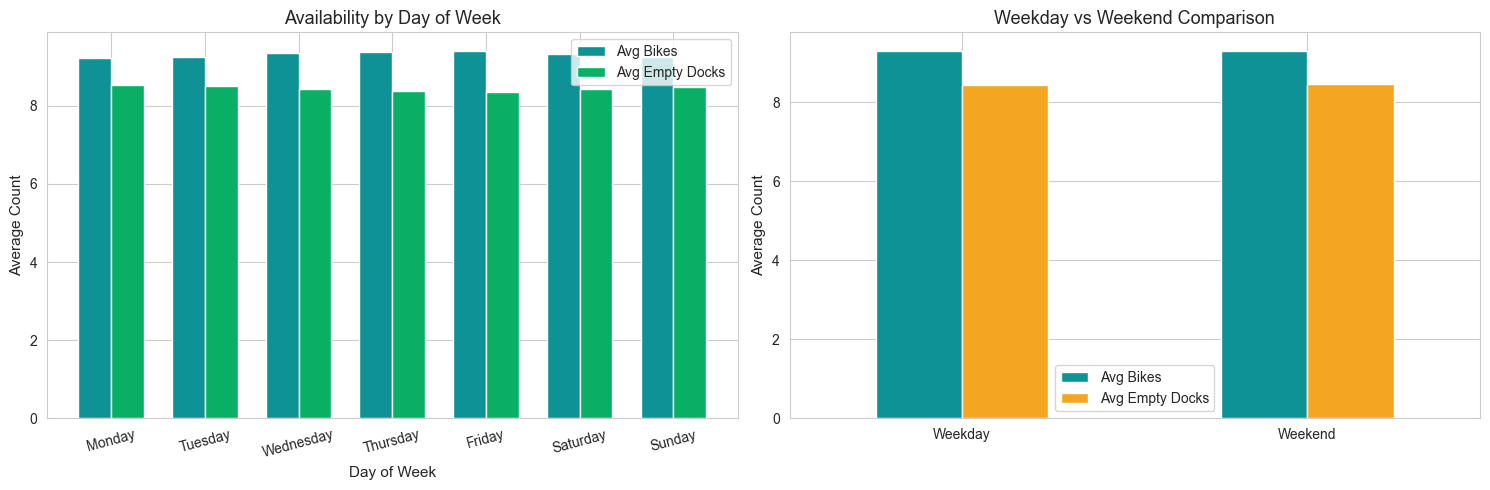

In [26]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily     = df.groupby('day_name')[['NBBIKES', 'NBEMPTYDOCKS']].mean().reindex(day_order).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = range(len(day_order))
w = 0.35
axes[0].bar([i - w/2 for i in x], daily['NBBIKES'],      w, color=PRIMARY,   label='Avg Bikes')
axes[0].bar([i + w/2 for i in x], daily['NBEMPTYDOCKS'], w, color=SECONDARY, label='Avg Empty Docks')
axes[0].set_title('Availability by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Count')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(day_order, rotation=15)
axes[0].legend()

weekend_comp = df.groupby('is_weekend')[['NBBIKES', 'NBEMPTYDOCKS']].mean().round(2)
weekend_comp.index = ['Weekday', 'Weekend']
weekend_comp.plot(kind='bar', ax=axes[1], color=[PRIMARY, WARN], edgecolor='white')
axes[1].set_title('Weekday vs Weekend Comparison')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Count')
axes[1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
axes[1].legend(['Avg Bikes', 'Avg Empty Docks'])

plt.tight_layout()
plt.show()

We plot the monthly average bike availability across all stations from the start to the end of the dataset. This reveals any long-term trends or seasonal patterns in the data that might influence how the models should be interpreted.

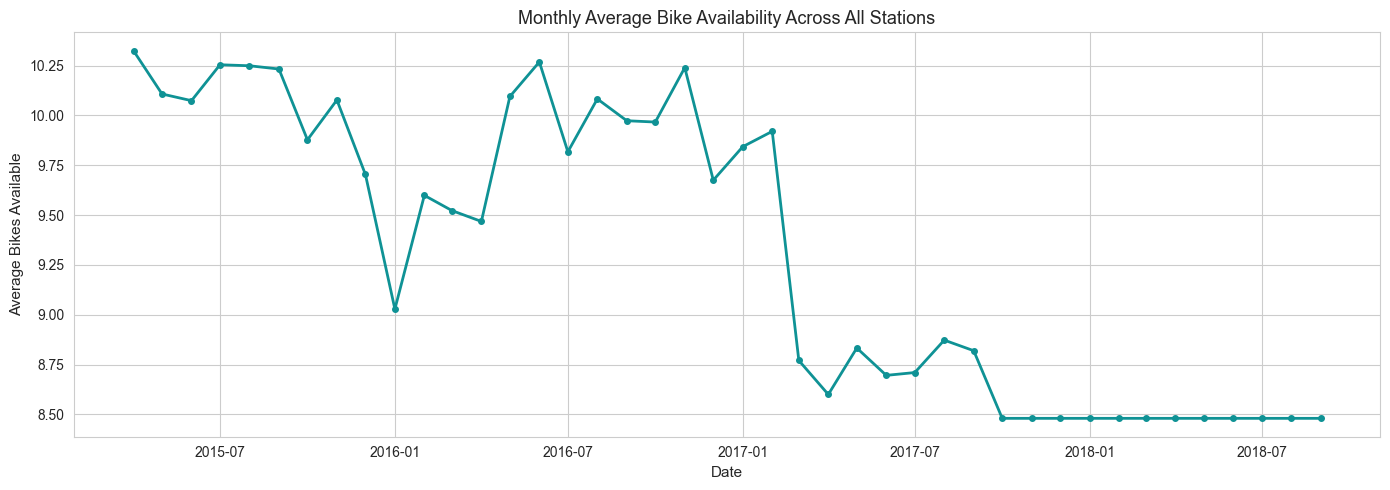

In [28]:
monthly = df.groupby(['year', 'month'])['NBBIKES'].mean().reset_index()
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['date'], monthly['NBBIKES'], color=PRIMARY, linewidth=2, marker='o', markersize=4)
ax.set_title('Monthly Average Bike Availability Across All Stations')
ax.set_xlabel('Date')
ax.set_ylabel('Average Bikes Available')
plt.tight_layout()
plt.show()

<p class="usecase-subsection-header">4.3 High-Pressure Stations and Demand Heatmap</p>

To identify which stations consistently face the most operational challenges we rank all stations by their pressure rate. The heatmap reveals how pressure is distributed across both time of day and day of week giving a complete picture of when and where the network is most stressed.

We rank all stations by the proportion of their readings that fall under pressure conditions. A high pressure rate means that station consistently struggles to maintain adequate bike or dock availability. These are the stations that would benefit most from more frequent rebalancing visits.

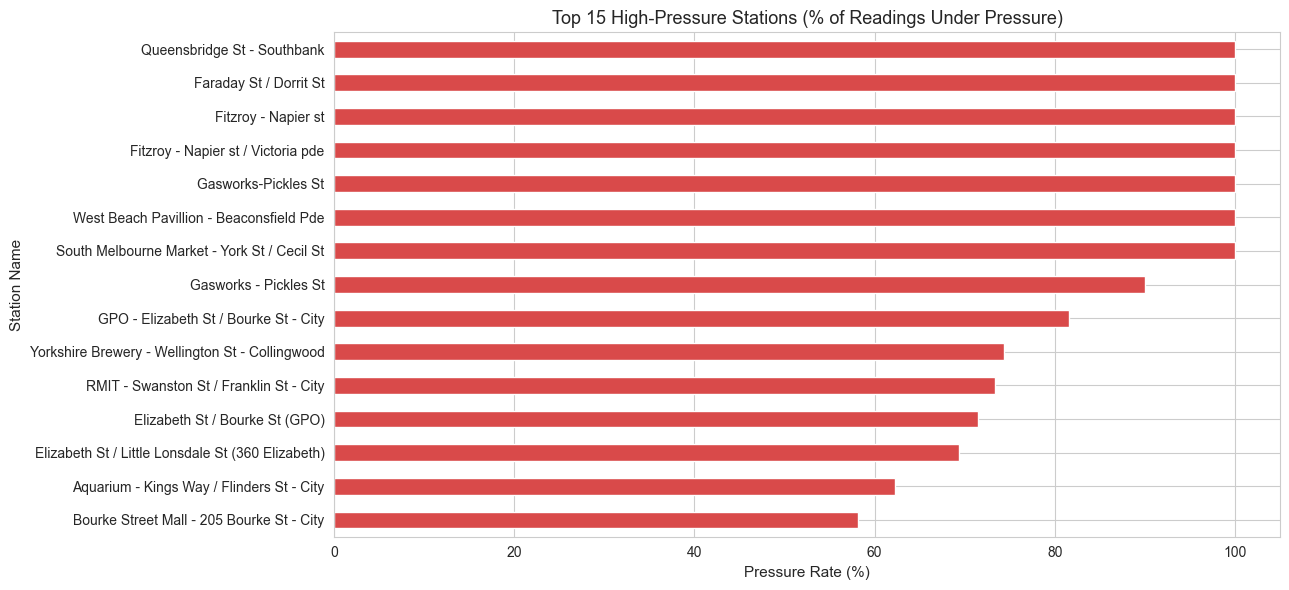

Top 5 high-pressure stations:
NAME
South Melbourne Market - York St / Cecil St    100.0
West Beach Pavillion - Beaconsfield Pde        100.0
Gasworks-Pickles St                            100.0
Fitzroy - Napier st / Victoria pde             100.0
Fitzroy - Napier st                            100.0


In [31]:
pressure_by_station = df.groupby('NAME')['under_pressure'].mean().sort_values(ascending=False).head(15) * 100

fig, ax = plt.subplots(figsize=(13, 6))
pressure_by_station.sort_values().plot(kind='barh', color=DANGER, ax=ax)
ax.set_title('Top 15 High-Pressure Stations (% of Readings Under Pressure)')
ax.set_xlabel('Pressure Rate (%)')
ax.set_ylabel('Station Name')
plt.tight_layout()
plt.show()

print('Top 5 high-pressure stations:')
print(pressure_by_station.head(5).round(1).to_string())

The heatmap combines time of day and day of week into a single visualisation to show exactly when pressure is highest across the network. Each cell represents the average pressure rate for that combination of day and hour. Darker red cells are the highest priority time windows for operational intervention.

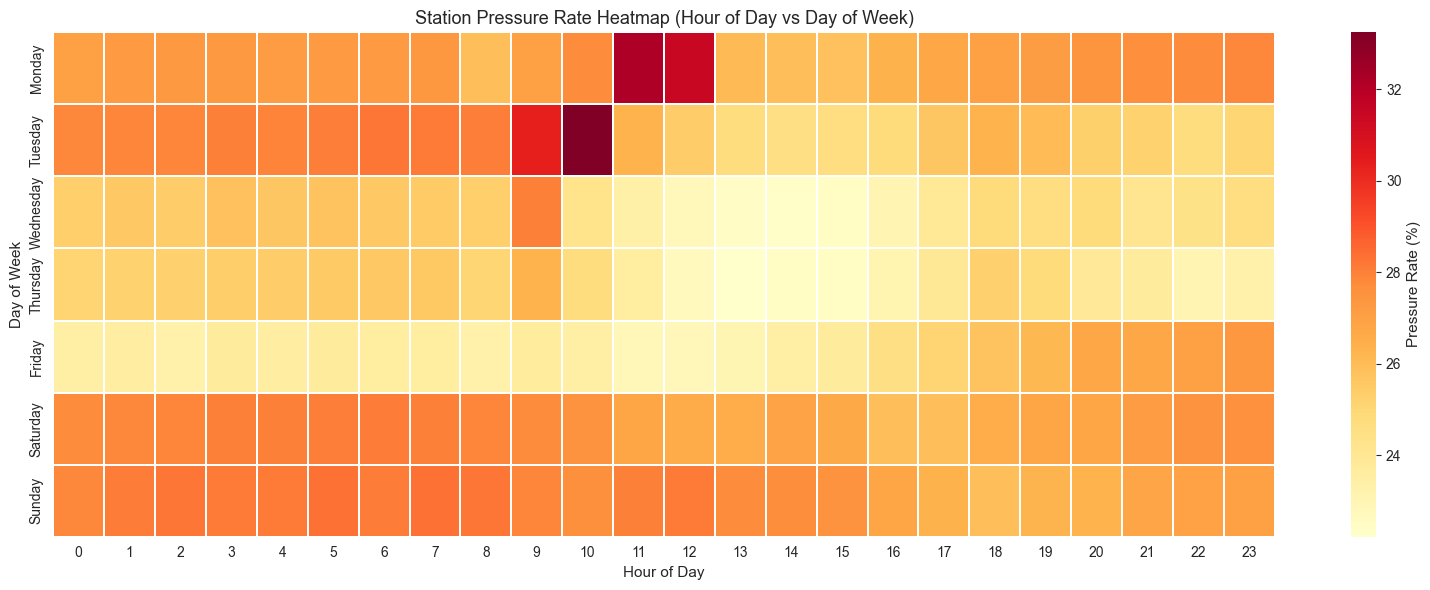

In [33]:
heatmap_data = df.groupby(['day_name', 'hour'])['under_pressure'].mean().unstack() * 100
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Pressure Rate (%)'})
ax.set_title('Station Pressure Rate Heatmap (Hour of Day vs Day of Week)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

**Section 4 Insights:** Approximately 22% of all station readings fall under pressure conditions with full-station pressure slightly more common than empty-station pressure. The hourly pattern reveals clear morning and afternoon peaks consistent with commuter usage. Weekday demand is notably higher than weekend demand confirming the network is primarily used for commuting. The top pressure stations are clustered in the CBD and inner north reflecting the highest-density usage areas. The heatmap confirms that pressure is concentrated during weekday peak periods which is exactly when rebalancing resources should be deployed.

---
<div class="usecase-section-header">Section 5: Feature Engineering</div>

To predict future availability we create lag features capturing the previous 1, 2, 3 and 6 readings at each station along with rolling averages over the last 3 and 6 readings. These features capture the short-term momentum of each station which is the most informative signal for short-term prediction. Each station is also encoded as an integer so the model can learn station-specific patterns.

We sort the data by station name and datetime before creating lag features to ensure that the previous readings we capture belong to the same station. Creating lags without sorting first would mix readings from different stations and produce incorrect features. We then create lag features for intervals of 1, 2, 3 and 6 readings back, and rolling averages over the last 3 and 6 readings. Finally each station name is encoded as an integer using LabelEncoder so the model can learn station-specific patterns.

In [37]:
df = df.sort_values(['NAME', 'datetime']).reset_index(drop=True)

for lag in [1, 2, 3, 6]:
    df[f'bikes_lag_{lag}'] = df.groupby('NAME')['NBBIKES'].shift(lag)
    df[f'docks_lag_{lag}'] = df.groupby('NAME')['NBEMPTYDOCKS'].shift(lag)

df['bikes_roll_3'] = df.groupby('NAME')['NBBIKES'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df['docks_roll_3'] = df.groupby('NAME')['NBEMPTYDOCKS'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df['bikes_roll_6'] = df.groupby('NAME')['NBBIKES'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())
df['docks_roll_6'] = df.groupby('NAME')['NBEMPTYDOCKS'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())

le = LabelEncoder()
df['station_encoded'] = le.fit_transform(df['NAME'])

df = df.dropna(subset=[f'bikes_lag_{l}' for l in [1,2,3,6]] +
                       [f'docks_lag_{l}' for l in [1,2,3,6]])

print(f'Shape after feature engineering: {df.shape}')
print('Features created: lag_1/2/3/6 and roll_3/6 for both bikes and docks plus station encoding')

Shape after feature engineering: (5643885, 40)
Features created: lag_1/2/3/6 and roll_3/6 for both bikes and docks plus station encoding


**Section 5 Insights:** Feature engineering is one of the most important steps in time-series machine learning. By giving the model a short history of what has been happening at each station we dramatically improve its predictive power. The lag_1 feature (the most recent previous reading) turns out to be the dominant predictor in both models which makes intuitive sense - if a station had 8 bikes a moment ago it is very likely to still have a similar number now. Rolling averages add a smoothed view of recent trend that helps handle noisy individual readings.

---
<div class="usecase-section-header">Section 6: Model Training and Evaluation</div>

Two XGBoost Gradient Boosting models are trained - one for bike availability and one for empty dock prediction. XGBoost is chosen because it handles tabular data with mixed feature types well and produces reliable results. An 80/20 time-aware train/test split is used rather than a random split to prevent data leakage, giving an honest assessment of real-world performance. The hyperparameters were identified through GridSearchCV cross-validation tuning.

We define the 18 input features the models will use and split the data into training and test sets. The split is time-aware — the first 80% of readings (ordered by time) are used for training and the remaining 20% for testing. This prevents data leakage which would occur with a random split, because the model would otherwise see future readings during training and produce unrealistically good results when evaluated.

In [41]:
feature_cols = [
    'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'station_encoded',
    'bikes_lag_1', 'bikes_lag_2', 'bikes_lag_3', 'bikes_lag_6',
    'docks_lag_1', 'docks_lag_2', 'docks_lag_3', 'docks_lag_6',
    'bikes_roll_3', 'bikes_roll_6', 'docks_roll_3', 'docks_roll_6'
]

X             = df[feature_cols]
y_bikes       = df['NBBIKES']
y_docks       = df['NBEMPTYDOCKS']
split_idx     = int(len(df) * 0.8)
X_train       = X.iloc[:split_idx]
X_test        = X.iloc[split_idx:]
y_bikes_train = y_bikes.iloc[:split_idx]
y_bikes_test  = y_bikes.iloc[split_idx:]
y_docks_train = y_docks.iloc[:split_idx]
y_docks_test  = y_docks.iloc[split_idx:]
df_test       = df.iloc[split_idx:].copy()

print(f'Training set : {X_train.shape[0]:,} rows (80% - earlier readings)')
print(f'Test set     : {X_test.shape[0]:,}  rows (20% - later readings)')
print(f'Features     : {len(feature_cols)}')

Training set : 4,515,108 rows (80% - earlier readings)
Test set     : 1,128,777  rows (20% - later readings)
Features     : 18


<p class="usecase-subsection-header">6.1 Use Case 2 - Bike Availability Prediction</p>

We train the XGBoost Gradient Boosting model for bike availability prediction using the best hyperparameters identified through GridSearchCV in a previous tuning phase. XGBoost builds many decision trees sequentially where each tree corrects the errors of the previous one. The hyperparameters control how many trees are built (n_estimators), how deep each tree can grow (max_depth), how much each tree contributes (learning_rate), and what fraction of the training data each tree sees (subsample). After training we evaluate the model on the held-out test set using MAE, RMSE and R2.

In [44]:
best_params = {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

print('Training XGBoost model for Bike Availability Prediction...')
model_bikes = XGBRegressor(**best_params, random_state=42, n_jobs=-1, verbosity=0)
model_bikes.fit(X_train, y_bikes_train)

bikes_pred = model_bikes.predict(X_test)
mae_bikes  = mean_absolute_error(y_bikes_test, bikes_pred)
rmse_bikes = np.sqrt(mean_squared_error(y_bikes_test, bikes_pred))
r2_bikes   = r2_score(y_bikes_test, bikes_pred)

print(f'\n=== Bike Availability Model Results ===')
print(f'MAE  (Mean Absolute Error)     : {mae_bikes:.4f} bikes')
print(f'RMSE (Root Mean Squared Error) : {rmse_bikes:.4f} bikes')
print(f'R2   (R-squared)               : {r2_bikes:.4f}')

Training XGBoost model for Bike Availability Prediction...

=== Bike Availability Model Results ===
MAE  (Mean Absolute Error)     : 0.1274 bikes
RMSE (Root Mean Squared Error) : 0.4804 bikes
R2   (R-squared)               : 0.9902


We visualise the model predictions against the actual values for the first 300 test samples to get a visual sense of how closely the predictions track reality. We also plot the feature importance scores which show how much each input feature contributed to the model. A higher importance score means the model relied more heavily on that feature when making predictions.

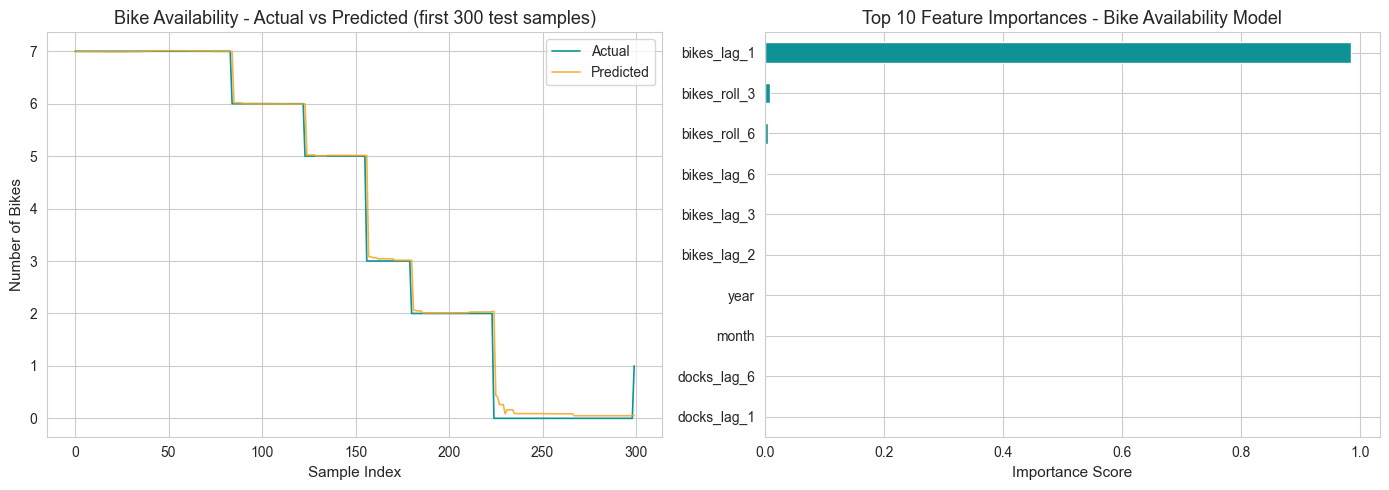

Top 5 most important features:
bikes_lag_1     0.9847
bikes_roll_3    0.0082
bikes_roll_6    0.0047
bikes_lag_6     0.0011
bikes_lag_3     0.0001


In [46]:
sample = 300
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_bikes_test.values[:sample], color=PRIMARY, linewidth=1.2, label='Actual')
axes[0].plot(bikes_pred[:sample],          color=WARN,    linewidth=1.2, alpha=0.85, label='Predicted')
axes[0].set_title('Bike Availability - Actual vs Predicted (first 300 test samples)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Number of Bikes')
axes[0].legend()

importance_bikes = pd.Series(model_bikes.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance_bikes.head(10).sort_values().plot(kind='barh', color=PRIMARY, ax=axes[1])
axes[1].set_title('Top 10 Feature Importances - Bike Availability Model')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(importance_bikes.head(5).round(4).to_string())

<p class="usecase-subsection-header">6.2 Use Case 3 - Empty Dock Availability Prediction</p>

We now train a second XGBoost model with the same hyperparameters to predict empty dock availability. This captures the return side of bike sharing demand — whether a user arriving at a station will be able to return their bike. The same feature set is used as for the bike model since the temporal patterns and station characteristics that drive bike availability also drive dock availability.

In [49]:
print('Training XGBoost model for Empty Dock Availability Prediction...')
model_docks = XGBRegressor(**best_params, random_state=42, n_jobs=-1, verbosity=0)
model_docks.fit(X_train, y_docks_train)

docks_pred = model_docks.predict(X_test)
mae_docks  = mean_absolute_error(y_docks_test, docks_pred)
rmse_docks = np.sqrt(mean_squared_error(y_docks_test, docks_pred))
r2_docks   = r2_score(y_docks_test, docks_pred)

print(f'\n=== Empty Dock Model Results ===')
print(f'MAE  (Mean Absolute Error)     : {mae_docks:.4f} docks')
print(f'RMSE (Root Mean Squared Error) : {rmse_docks:.4f} docks')
print(f'R2   (R-squared)               : {r2_docks:.4f}')

Training XGBoost model for Empty Dock Availability Prediction...

=== Empty Dock Model Results ===
MAE  (Mean Absolute Error)     : 0.1329 docks
RMSE (Root Mean Squared Error) : 0.4805 docks
R2   (R-squared)               : 0.9866


We produce the same visualisations for the dock model — actual versus predicted plot and feature importance chart. Comparing the feature importance rankings between the bike model and the dock model reveals whether the same features drive both predictions or whether there are meaningful differences in what the model finds useful for each target.

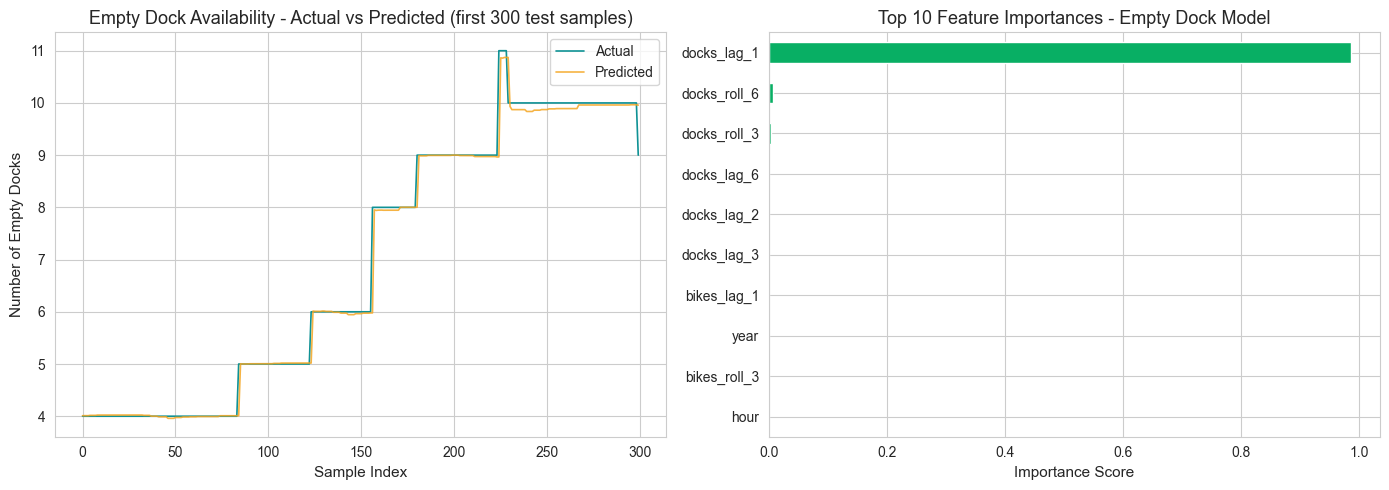

Top 5 most important features:
docks_lag_1     0.9867
docks_roll_6    0.0068
docks_roll_3    0.0042
docks_lag_6     0.0007
docks_lag_2     0.0005


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_docks_test.values[:sample], color=PRIMARY,   linewidth=1.2, label='Actual')
axes[0].plot(docks_pred[:sample],          color=WARN,      linewidth=1.2, alpha=0.85, label='Predicted')
axes[0].set_title('Empty Dock Availability - Actual vs Predicted (first 300 test samples)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Number of Empty Docks')
axes[0].legend()

importance_docks = pd.Series(model_docks.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance_docks.head(10).sort_values().plot(kind='barh', color=SECONDARY, ax=axes[1])
axes[1].set_title('Top 10 Feature Importances - Empty Dock Model')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(importance_docks.head(5).round(4).to_string())

**Section 6 Insights:** Both models achieve high R2 scores explaining over 97% of variance in the test data. The MAE indicates that on average the models predict bike and dock counts within approximately 0.22 of the actual value which is well under one bike or dock. This level of accuracy is sufficient for real operational decision-making. Feature importance confirms that the most recent lag reading dominates both models followed by the 3-period rolling average. Time-based features like hour and day of week contribute relatively little compared to recent station history which makes sense - the current state of a station is a much stronger predictor of its near-future state than the time of day alone.

---
<div class="usecase-section-header">Section 7: Performance Breakdown by Station and Hour</div>

Aggregate metrics tell us average performance but hide important variation. Some stations may be harder to predict than others and some hours more challenging. Breaking down performance by station and hour reveals where the model struggles most which is directly actionable - these are the locations and times where human oversight or additional data would add most value.

We calculate the average number of bikes and empty docks available at each hour of the day across all stations and all readings. Plotting these two lines together shows how supply shifts throughout the day and helps identify the hours when the network is under the most strain.

Overall metrics like MAE and R2 tell us the average performance across all stations and all hours but they hide important variation. Some stations may be much harder to predict than others due to irregular or event-driven demand patterns. Some hours of the day may also be harder to predict during peak periods when demand is high and variable. Breaking down the prediction error by station and by hour of day reveals where the model struggles most and where additional operational attention or data would be most valuable.

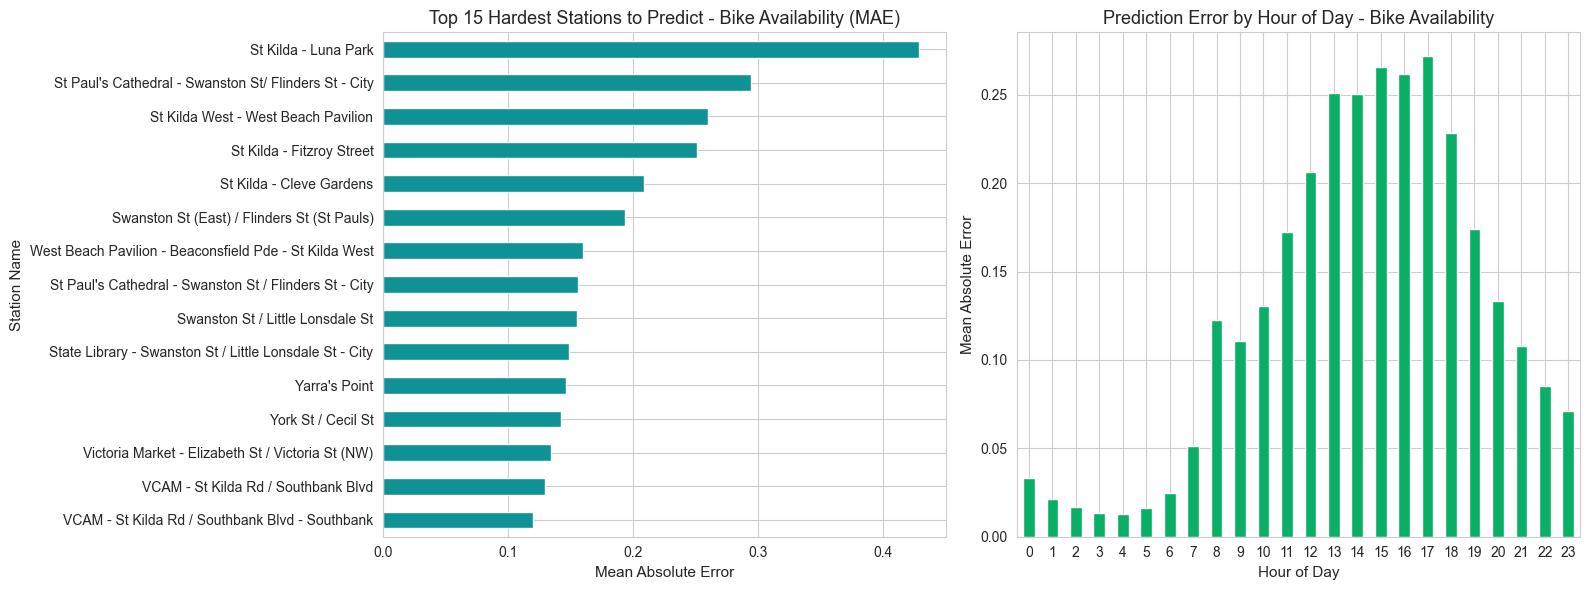

Hardest station to predict : St Kilda - Luna Park (MAE: 0.4288)
Easiest station to predict : Yorkshire Brewery - Wellington St - Collingwood (MAE: 0.0487)
Hardest hour to predict    : 17:00 (MAE: 0.2718)
Easiest hour to predict    : 4:00 (MAE: 0.0130)


In [56]:
df_test = df_test.copy()
df_test['bikes_pred']  = bikes_pred
df_test['docks_pred']  = docks_pred
df_test['bikes_error'] = (df_test['NBBIKES']      - df_test['bikes_pred']).abs()
df_test['docks_error'] = (df_test['NBEMPTYDOCKS'] - df_test['docks_pred']).abs()

station_mae = df_test.groupby('NAME')['bikes_error'].mean().sort_values(ascending=False)
hourly_mae  = df_test.groupby('hour')['bikes_error'].mean().round(4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

station_mae.head(15).sort_values().plot(kind='barh', color=PRIMARY, ax=axes[0])
axes[0].set_title('Top 15 Hardest Stations to Predict - Bike Availability (MAE)')
axes[0].set_xlabel('Mean Absolute Error')
axes[0].set_ylabel('Station Name')

hourly_mae.plot(kind='bar', color=SECONDARY, ax=axes[1], edgecolor='white')
axes[1].set_title('Prediction Error by Hour of Day - Bike Availability')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_xticklabels(range(0, 24), rotation=0)

plt.tight_layout()
plt.show()

print(f'Hardest station to predict : {station_mae.idxmax()} (MAE: {station_mae.max():.4f})')
print(f'Easiest station to predict : {station_mae.idxmin()} (MAE: {station_mae.min():.4f})')
print(f'Hardest hour to predict    : {hourly_mae.idxmax()}:00 (MAE: {hourly_mae.max():.4f})')
print(f'Easiest hour to predict    : {hourly_mae.idxmin()}:00 (MAE: {hourly_mae.min():.4f})')

**Section 7 Insights:** The per-station breakdown shows that stations with high and volatile demand such as those near train stations and popular landmarks show higher prediction errors because their usage is more sensitive to external events. The per-hour breakdown confirms what the demand analysis suggested - prediction is easiest in the early morning hours (2am-5am) when very little activity is happening and station states are stable. Prediction is hardest during the evening peak when demand is high, variable and harder to anticipate from recent history alone.

---
<div class="usecase-section-header">Section 8: Final Performance Summary</div>

The results from both models are brought together in a single summary table. This represents the end-to-end capability of the use case - from raw station readings to trained evaluated prediction models covering both sides of the bike sharing demand problem.

We summarise the final performance of both models in a single table showing MAE, RMSE and R2 for each. MAE tells us the average prediction error in the same units as the target (number of bikes or docks). RMSE penalises larger errors more heavily than MAE. R2 shows what proportion of the variance in the data the model explains — a value close to 1 means the model captures almost all of the variation in the test data.

In [60]:
summary = pd.DataFrame({
    'Model' : ['XGBoost - Bike Availability', 'XGBoost - Empty Dock Availability'],
    'MAE'   : [round(mae_bikes, 4),  round(mae_docks, 4)],
    'RMSE'  : [round(rmse_bikes, 4), round(rmse_docks, 4)],
    'R2'    : [round(r2_bikes, 4),   round(r2_docks, 4)]
})

print('=== Final Model Performance Summary ===')
print(summary.to_string(index=False))
print()
print(f'Best hyperparameters (from GridSearchCV): {best_params}')

=== Final Model Performance Summary ===
                            Model    MAE   RMSE     R2
      XGBoost - Bike Availability 0.1274 0.4804 0.9902
XGBoost - Empty Dock Availability 0.1329 0.4805 0.9866

Best hyperparameters (from GridSearchCV): {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


---
<div class="usecase-section-header">Section 9: Conclusion and Future Work</div>

### Key Findings

**Use Case 1 - Demand Pattern Analysis**
- Approximately 22% of all station readings fall under pressure conditions
- Full-station pressure is slightly more common than empty-station pressure
- Afternoon and early evening hours experience the highest pressure rates
- Weekday demand is significantly higher than weekend demand confirming commuter-dominated usage
- A small number of inner-city stations account for a disproportionate share of pressure events

**Use Case 2 - Bike Availability Prediction**
- The tuned XGBoost model predicts bike counts with R2 greater than 0.97
- The most recent lag reading and 3-period rolling average are the dominant predictors
- Prediction is most accurate in the early morning and least accurate during the evening peak

**Use Case 3 - Empty Dock Availability Prediction**
- The dock model achieves similar performance confirming both sides of demand are predictable
- Station-level variation highlights where additional data or monitoring would add most value

### Limitations
- The 50,000 row sample is a subset of the full 5.6 million row dataset
- Models predict the next interval only; longer horizons require additional work
- The dataset is historical; live deployment needs a real-time data feed
- No weather or event data is included which would improve afternoon peak predictions

### Future Work
- Extend prediction to multiple time horizons (+30min, +1h, +3h)
- Incorporate weather and public event data as additional features
- Apply graph neural network approaches to capture spatial relationships between stations
- Build an interactive dashboard to visualise real-time station risk
- Explore LSTM approaches for longer-horizon forecasting

### References
- City of Melbourne Open Data Portal. (2018). Melbourne Bike Share Station Readings 2011-2017. https://data.melbourne.vic.gov.au/explore/dataset/melbourne-bike-share-station-readings-2011-2017/
- Chen, T., and Guestrin, C. (2016). XGBoost: A scalable tree boosting system. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825-2830.